In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [2]:
# Normalization and data augmentation
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]) # ImageNet standard
])

In [3]:
train_dataset = datasets.ImageFolder("tumor_dataset/Training", transform=transform)
test_dataset = datasets.ImageFolder("tumor_dataset/Testing", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

print(train_dataset.class_to_idx)

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [4]:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4) # 4 classes: glioma, meningioma, pituitary, no tumor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/home/jonathan/Desktop/medical-imaging/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jonathan/Desktop/medical-imaging/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

### <center>Training</center>

In [6]:
epochs = 25

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.5f}")

Epoch 1, Loss: 0.36812
Epoch 2, Loss: 0.12179
Epoch 3, Loss: 0.08823
Epoch 4, Loss: 0.05840
Epoch 5, Loss: 0.05602
Epoch 6, Loss: 0.02683
Epoch 7, Loss: 0.01393
Epoch 8, Loss: 0.02539
Epoch 9, Loss: 0.02432
Epoch 10, Loss: 0.01509
Epoch 11, Loss: 0.02227
Epoch 12, Loss: 0.02188
Epoch 13, Loss: 0.01777
Epoch 14, Loss: 0.02376
Epoch 15, Loss: 0.01473
Epoch 16, Loss: 0.01419
Epoch 17, Loss: 0.00799
Epoch 18, Loss: 0.00510
Epoch 19, Loss: 0.01579
Epoch 20, Loss: 0.01690
Epoch 21, Loss: 0.00831
Epoch 22, Loss: 0.01182
Epoch 23, Loss: 0.00291
Epoch 24, Loss: 0.01034
Epoch 25, Loss: 0.00966


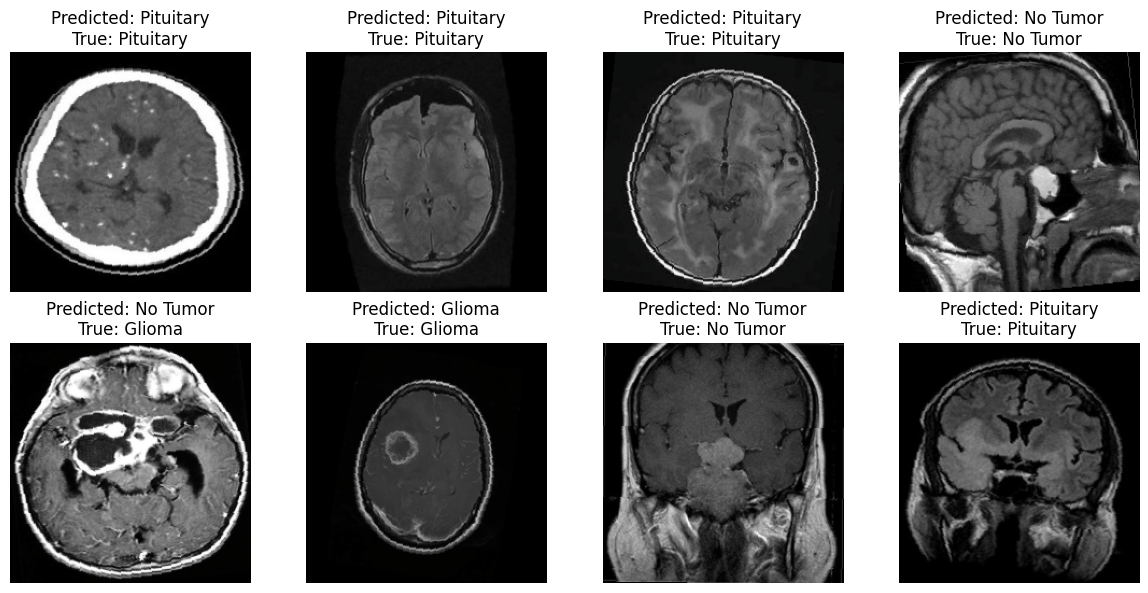

In [7]:
import numpy as np
import matplotlib.pyplot as plt

classes = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]

# Get batch of test images
images, labels = next(iter(test_loader))

outputs = model(images.to(device))
_, preds = torch.max(outputs,1)

# Display predictions & actual labels
num_images = min(len(images), 8) # 8 images
cols = 4
rows = (num_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
std  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)

for idx in range(num_images):
    ax = axes[idx]
    img = images[idx].cpu().numpy()
    img = img * std + mean
    img = np.clip(img,0,1)
    ax.imshow(np.transpose(img, (1,2,0)))
    pred_label = classes[preds[idx].item()]
    true_label = classes[labels[idx].item()]
    ax.set_title(f"Predicted: {pred_label}\nTrue: {true_label}")
    ax.axis('off')

# Turn off unused subplots
for ax in axes[num_images:]:
    ax.axis('off')

plt.tight_layout()
plt.show()